In [84]:
import json
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from umap.umap_ import UMAP
import seaborn as sns
from datasets import load_dataset, Dataset
from huggingface_hub import login

In [29]:
with open('../configs/generation_config.yaml', 'r') as file:
    generation_config = yaml.safe_load(file)
        
with open('../psychometric_tests/hexaco_100_eval.yaml', 'r') as file:
    hexaco_eval = yaml.safe_load(file)

In [30]:
def load_personas(hf_persona_path,n_personasample):
    
    print("Using Huggingface Personas")
    print(f"Loading Personas from {hf_persona_path}")
    hf_persona_dataset = load_dataset(hf_persona_path)
    persona_datasets_total = hf_persona_dataset['train']
    total_persona_df = persona_datasets_total.to_pandas()
    persona_datasets = total_persona_df.groupby("archetype").sample(n=n_personasample, random_state=42)
    print(f"No of Personas: {persona_datasets.shape[0]}")
    return persona_datasets

In [31]:
def write_to_json(file, file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, 'w') as f:
        json.dump(file, f, indent=2)


def read_json(file_path):
    with open(file_path, "r") as f:
        return json.load(f)
    
def get_model_name(filename, file_str):
    model_name = filename.replace("_hexaco_answers_","").replace(".json","").replace(file_str,"")
    return model_name

In [32]:
def calculate_hexaco_score(trait, subtrait, answers, likert_scale = generation_config['likert_scale']):
    # answer_dict = {}
    answers = [answer if answer in likert_scale else "Do not wish to answer" for answer in answers]
    answers = pd.Series(answers)
    subtrait_dict = hexaco_eval[trait][subtrait]
    indices = [idx - 1 for idx in subtrait_dict['indices']]
    trait_answers = answers[indices]
    refused_answers = trait_answers[trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    non_refused_answers = trait_answers[~trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    answer_indices = [likert_scale.index(answer) + 1 for answer in non_refused_answers]
    # print(answer_indices)
    true_answer_indices = [6-idx if reverse else idx for idx,reverse in zip(answer_indices, subtrait_dict['reverse'])]
    
    # answer_dict['answer_indices'] = answer_indices
    # answer_dict['true_answer_indices'] = true_answer_indices
    # answer_dict['n_answered_questions'] = len(true_answer_indices)
    # answer_dict['n_refused_questions'] = len(refused_answers)
    # answer_dict['trait'] = trait
    # answer_dict['subtrait'] = subtrait
    # answer_dict['subtrait_score'] = np.round(np.mean(true_answer_indices).item(),3)
    return true_answer_indices

def get_trait_scores(answer,likert_scale = generation_config['likert_scale']):
    trait_score = []
    for trait in hexaco_eval.keys():
        for subtrait in hexaco_eval[trait].keys():
            trait_true_answer_indices = []
            trait_true_answer_indices.extend(calculate_hexaco_score(trait, subtrait, answer, likert_scale))
        
        trait_score.append(np.round(np.mean(trait_true_answer_indices).item(),3).item())
    return trait_score

In [14]:
zero_compute_data_dir = "../experiment_results/zero_compute_analysis_hexaco/"

In [33]:
hexaco_mapping = {"Strongly Disagree": -2, "Disagree": -1, "Neutral": 0, "Agree": 1, "Strongly Agree":2, "Do not wish to answer": -3}
trait_list = ['honest-humility','emotionality','extraversion','agreeableness','conscientiousness','openness to experience','altruism']

huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1822530561.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_gpt-4_1.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1822530561.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1822530561.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


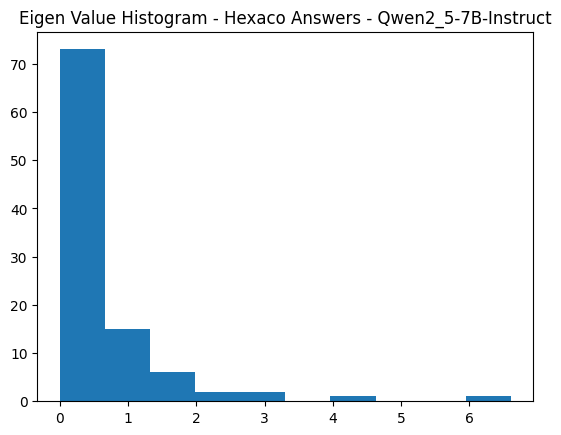

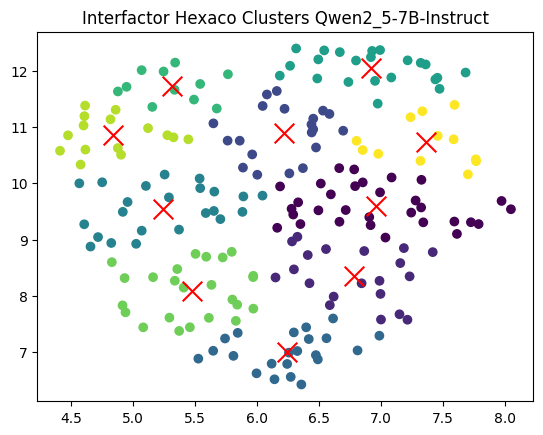

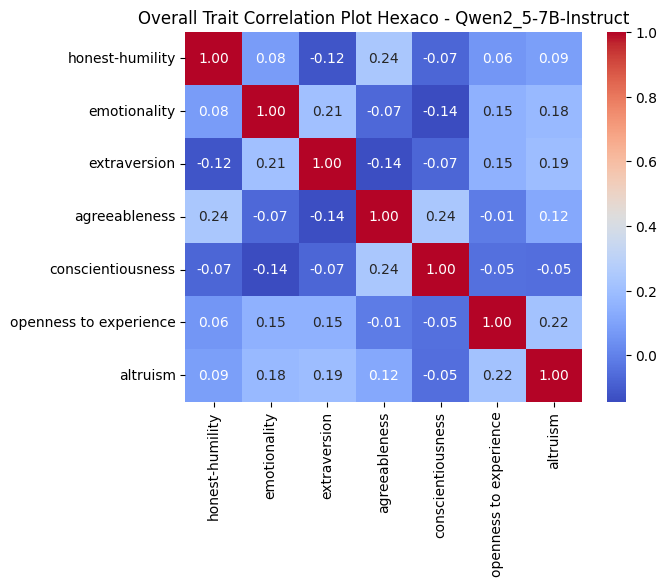

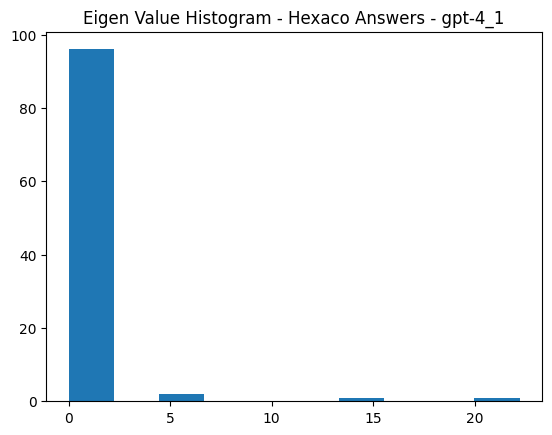

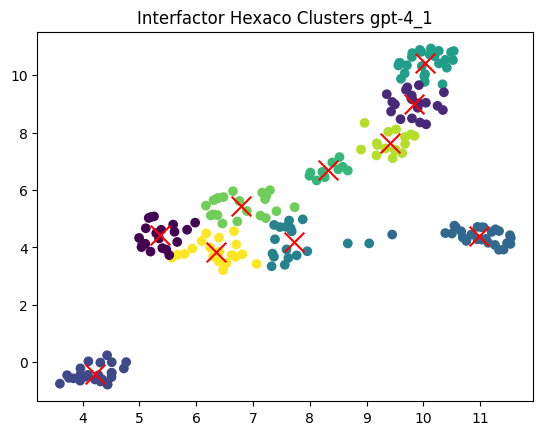

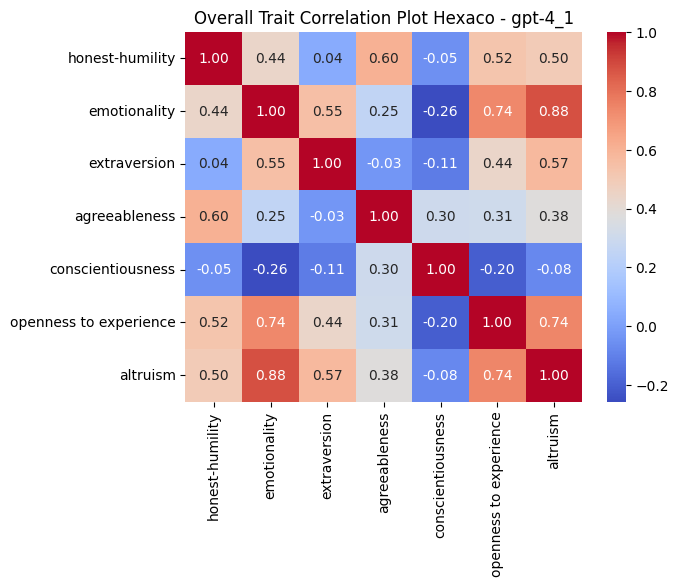

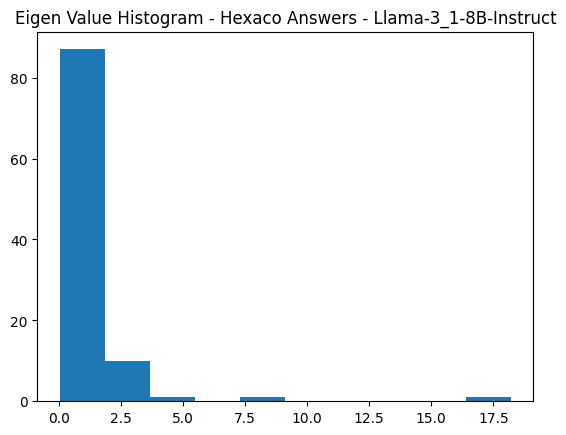

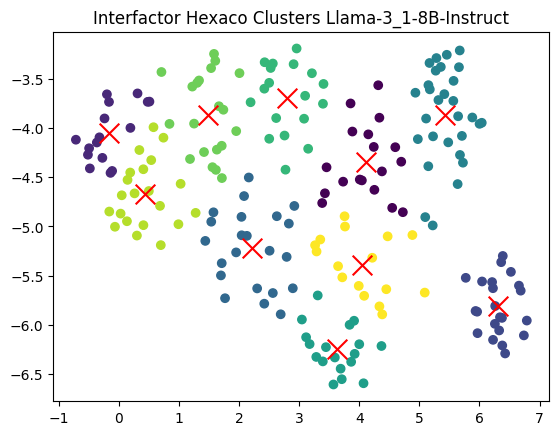

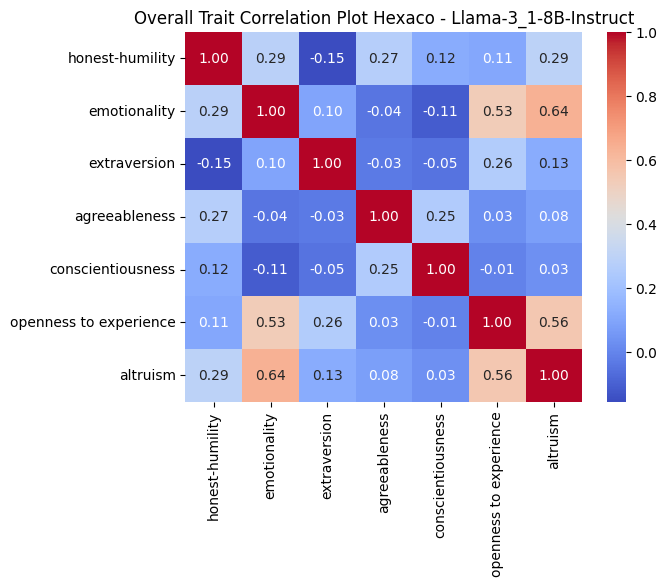

In [122]:
file_str = "huggingface"
# hf_hexaco_trait_persona_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_hexaco_results = read_json(os.path.join(zero_compute_data_dir, filename))
        persona_hexaco_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": hf_persona_hexaco_results[key]['answers'][0]} for key in hf_persona_hexaco_results.keys()])

        persona_hexaco_str_answers_df = pd.DataFrame(persona_hexaco_str_answers_df['answers'].to_list(), columns = list(range(0,100)), index = persona_hexaco_str_answers_df['persona_id'])
        persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
        
        plt.figure()
        plt.hist(np.linalg.eigvals(np.cov(persona_hexaco_df.values.T)))
        plt.title(f"Eigen Value Histogram - Hexaco Answers - {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir,  "analysis_results",f"Eigen_histogram_hexaco_{model_name}"), dpi=300)
        
        umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        X_reduced = umap_model.fit_transform(persona_hexaco_df)
        
        kmeans_model = KMeans(n_clusters=10, random_state=42)
        kmeans_model.fit(X_reduced)
        
        labels = kmeans_model.labels_
        centroids = kmeans_model.cluster_centers_

        plt.figure()
        plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', marker='o')
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)
        plt.title(f"Interfactor Hexaco Clusters {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"interfactor_clusters_hexaco_{model_name}"), dpi=300)
        
        hexaco_trait_persona_df = pd.DataFrame(persona_hexaco_str_answers_df.apply(lambda x: get_trait_scores(x),axis = 1).to_list(), index = persona_hexaco_str_answers_df.index, columns = trait_list)

        # hexaco_trait_persona_df['cluster_labels'] = labels
        # hexaco_trait_persona_df['model_name'] = model_name
        # hf_hexaco_trait_persona_df = pd.concat([hf_hexaco_trait_persona_df,hexaco_trait_persona_df],axis = 0)
        
        
        plt.figure()
        sns.heatmap(np.corrcoef(hexaco_trait_persona_df.T - 3),annot=True, cmap="coolwarm", fmt=".2f", cbar=True,xticklabels=hexaco_trait_persona_df.columns,yticklabels=hexaco_trait_persona_df.columns)
        plt.title(f"Overall Trait Correlation Plot Hexaco - {model_name}")
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"trait_correlation_hexaco_{model_name}"),
                    bbox_inches='tight', dpi=300)

In [128]:
hexaco_trait_persona_df

,honest-humility,emotionality,extraversion,agreeableness,conscientiousness,openness to experience,altruism,model_name
persona_id,,,,,,,,
782f13f4-0d98-41b4-a170-a2839dc6be70,3.50,3.75,1.50,3.75,3.50,3.25,4.25,Llama-3_1-8B-Instruct
81596279-9ae8-463f-bb93-f8f0f88d777e,3.50,2.00,2.00,3.50,3.75,2.75,3.50,Llama-3_1-8B-Instruct
6ce72d58-d03e-46d3-ae63-28b1bad56c26,3.25,2.75,1.50,3.75,3.75,2.75,2.50,Llama-3_1-8B-Instruct
e960e68a-f260-48df-8cb7-d6f8a46e470a,3.50,3.00,2.00,3.25,3.00,2.75,3.25,Llama-3_1-8B-Instruct
e3d265c4-b172-44f0-b058-be4d42fe5fb4,3.25,2.25,1.50,2.75,3.50,2.75,3.50,Llama-3_1-8B-Instruct
...,...,...,...,...,...,...,...,...
197a10f3-35a9-4fda-8245-6a02c2980762,2.50,1.25,1.75,3.50,3.25,2.75,4.00,Llama-3_1-8B-Instruct
d1403dfc-c79b-4eb8-b017-372942ff3930,3.25,3.25,3.25,2.75,3.25,3.50,4.50,Llama-3_1-8B-Instruct
07406572-896a-42fe-bbc1-126104622bf7,3.00,1.75,3.25,3.00,3.75,3.25,3.50,Llama-3_1-8B-Instruct


In [123]:
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)

huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json
huggingface_hexaco_answers_gpt-4_1.json
huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


In [124]:
file_str = "huggingface"
hf_hexaco_trait_persona_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_hexaco_results = read_json(os.path.join(zero_compute_data_dir, filename))
        persona_hexaco_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": hf_persona_hexaco_results[key]['answers'][0]} for key in hf_persona_hexaco_results.keys()])

        persona_hexaco_str_answers_df = pd.DataFrame(persona_hexaco_str_answers_df['answers'].to_list(), columns = list(range(0,100)), index = persona_hexaco_str_answers_df['persona_id'])
        persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
        
        
        hexaco_trait_persona_df = pd.DataFrame(persona_hexaco_str_answers_df.apply(lambda x: get_trait_scores(x),axis = 1).to_list(), index = persona_hexaco_str_answers_df.index, columns = trait_list)

        # hexaco_trait_persona_df['cluster_labels'] = labels
        hexaco_trait_persona_df['model_name'] = model_name
        print(hf_hexaco_trait_persona_df.shape)
        hf_hexaco_trait_persona_df = pd.concat([hf_hexaco_trait_persona_df,hexaco_trait_persona_df],axis = 0)
        print(hf_hexaco_trait_persona_df.shape)

huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1816713311.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)


(0, 0)
(200, 8)
huggingface_hexaco_answers_gpt-4_1.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1816713311.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)


(200, 8)
(400, 8)
huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/1816713311.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)


(400, 8)
(600, 8)


hf_hexaco_trait_persona_df.reset_index().to_csv(os.path.join(zero_compute_data_dir, "hf_hexaco_trait_persona_df.csv"),index = False)

In [129]:
login("")
persona_datasets = load_personas("thoughtworks/psychometric_personas",25)

Using Huggingface Personas
Loading Personas from thoughtworks/psychometric_personas
No of Personas: 200


In [130]:
def hexaco_aggregation_by_attribute(hexaco_df, attribute):
        
    persona_df = persona_datasets[['uuid',attribute]].drop_duplicates()
    attribute_hexaco = pd.merge(hexaco_df, persona_df, left_on="persona_id", right_on="uuid", how = "inner")
    
    return attribute_hexaco.drop("uuid", axis = 1).groupby([attribute,'model_name'], as_index=False).mean()

## Hexaco Profile By Archetype

In [131]:
archetype_hexaco = hexaco_aggregation_by_attribute(hf_hexaco_trait_persona_df,attribute="archetype")

In [132]:
ethnic_hexaco = hexaco_aggregation_by_attribute(hf_hexaco_trait_persona_df,attribute="ethnic_background")

ethnic_background
white                       127
black                        23
mexican                      22
puerto rican                  6
cuban                         4
east asian                    4
hispanic or latino other      3
southeast asian               2
colombian                     1
peruvian                      1
honduran                      1
dominican                     1
spaniard                      1
south asian                   1
ecuadorian                    1
guatemalan                    1
spanish                       1
Name: count, dtype: int64

huggingface_hexaco_answers_Qwen2_5-7B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/2431787475.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_gpt-4_1.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/2431787475.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


huggingface_hexaco_answers_Llama-3_1-8B-Instruct.json


/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_67478/2431787475.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
/Users/shreyansjain/.pyenv/versions/3.11.9/envs/llm_psychometrics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


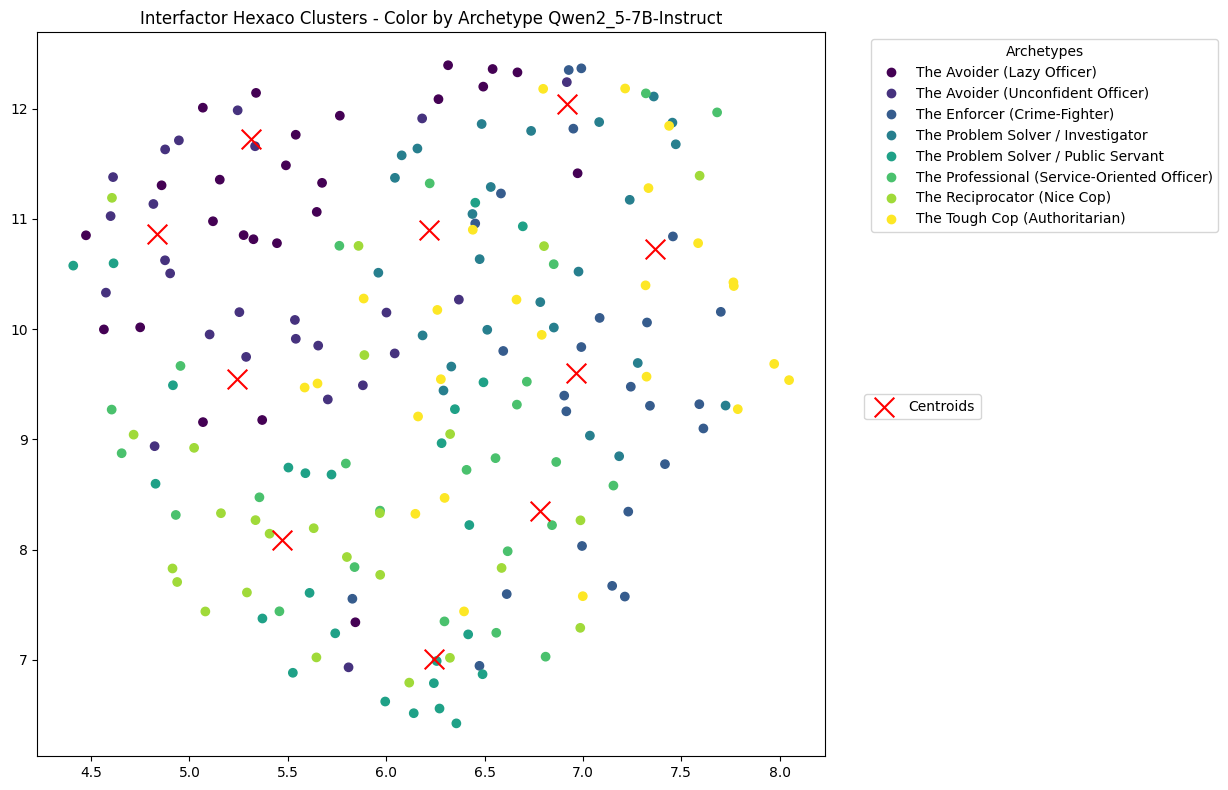

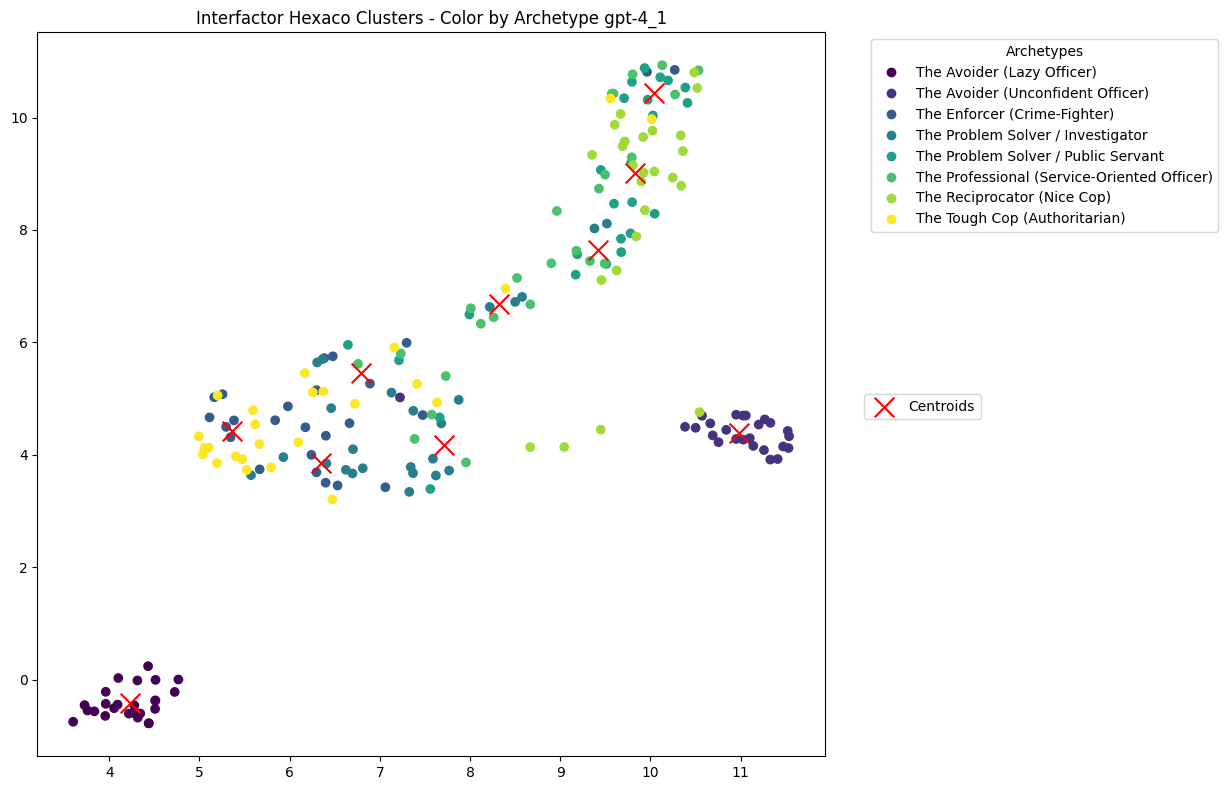

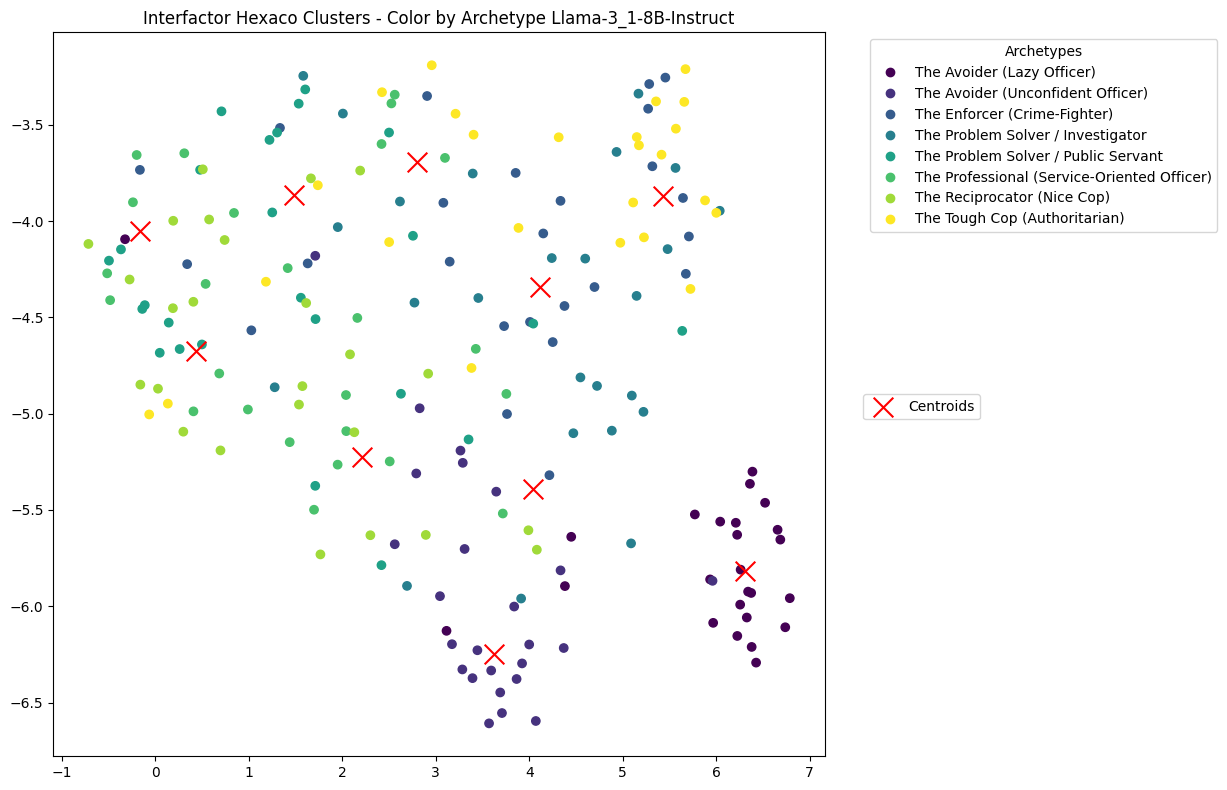

In [161]:
file_str = "huggingface"
# hf_hexaco_trait_persona_df = pd.DataFrame()
for filename in os.listdir(zero_compute_data_dir):
    if ".json" in filename:
        print(filename)
        
        model_name = get_model_name(filename, file_str)
        hf_persona_hexaco_results = read_json(os.path.join(zero_compute_data_dir, filename))
        persona_hexaco_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": hf_persona_hexaco_results[key]['answers'][0]} for key in hf_persona_hexaco_results.keys()])

        persona_hexaco_str_answers_df = pd.DataFrame(persona_hexaco_str_answers_df['answers'].to_list(), columns = list(range(0,100)), index = persona_hexaco_str_answers_df['persona_id'])
        persona_hexaco_df = persona_hexaco_str_answers_df.replace(hexaco_mapping)
        
        umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        X_reduced = umap_model.fit_transform(persona_hexaco_df)
        
        kmeans_model = KMeans(n_clusters=10, random_state=42)
        kmeans_model.fit(X_reduced)
        
        labels = kmeans_model.labels_
        centroids = kmeans_model.cluster_centers_
        
        archetype_labels = pd.merge(archetype_df, pd.Series(persona_hexaco_df.index), left_on = "uuid", how='inner', right_on="persona_id")['archetype']
        archetype_codes = archetype_labels.astype('category').cat.codes

        plt.figure(figsize=(10, 8))
        ax = plt.gca()

        # Plot archetypes and capture the returned PathCollection object
        scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=archetype_codes, cmap='viridis', marker='o')

        # Plot centroids and capture the returned PathCollection object
        centroids_scatter = ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)

        # Set the title
        ax.set_title(f"Interfactor Hexaco Clusters - Color by Archetype {model_name}")

        # Get the original category labels for the archetype legend
        labels = archetype_labels.astype('category').cat.categories

        # Create the legend for the archetypes from the scatter plot elements
        handles, _ = scatter.legend_elements(prop='colors')
        legend1 = ax.legend(handles, labels, title='Archetypes', bbox_to_anchor=(1.05, 1), loc='upper left')

        # Create the legend for the centroids manually
        # Use the handles from the centroids_scatter object
        legend2 = ax.legend([centroids_scatter], ['Centroids'], bbox_to_anchor=(1.05, 0.5), loc='upper left', borderaxespad=0.)

        # Add the first legend back to the axes, as the second call overrides it
        ax.add_artist(legend1)

        # Adjust layout to make room for the legend
        plt.tight_layout()

        # Save the figure, specifying the legends as extra artists
        plt.savefig(os.path.join(zero_compute_data_dir, "analysis_results",f"interfactor_clusters_hexaco_color_by_archetype{model_name}"), bbox_inches='tight', bbox_extra_artists=(legend1, legend2), dpi=300)
        

In [142]:
pd.Series(persona_hexaco_df.index)

0      782f13f4-0d98-41b4-a170-a2839dc6be70
1      81596279-9ae8-463f-bb93-f8f0f88d777e
2      6ce72d58-d03e-46d3-ae63-28b1bad56c26
3      e960e68a-f260-48df-8cb7-d6f8a46e470a
4      e3d265c4-b172-44f0-b058-be4d42fe5fb4
                       ...                 
195    197a10f3-35a9-4fda-8245-6a02c2980762
196    d1403dfc-c79b-4eb8-b017-372942ff3930
197    07406572-896a-42fe-bbc1-126104622bf7
198    f4acd364-3ff1-4cea-b016-1db3c3a7c5e7
199    b1d4bee8-bc52-4571-9714-7ca5e83bf5ad
Name: persona_id, Length: 200, dtype: object

['The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Lazy Officer)',
 'The Avoider (Unconfident Officer)',
 'The Avoider (Unconfident Officer)',
 'The Avoider (Unconfident Officer)',
 'The Avoider (Unconfident Officer)',
 'The Avoider (Unconfident Officer)',
 'The Avoider (Unconfident Officer)

In [133]:
archetype_df = persona_datasets[['uuid',"archetype"]].drop_duplicates()